In [ ]:
# ============================================================
# CELL 2 — Imports & Global Configuration
# ============================================================
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
import warnings
import os
import shap

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score,
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

os.makedirs("f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("f1_cache")

# ── F1 Colour System ────────────────────────────────────────
F1_BG        = "#0a0a0a"    # fundo principal
F1_PANEL     = "#111111"    # painéis
F1_CARD      = "#1a1a1a"    # cards / axes
F1_BORDER    = "#222222"    # bordas subtis
F1_RED       = "#E8002D"    # vermelho F1 oficial
F1_WHITE     = "#FFFFFF"
F1_SILVER    = "#C0C0C0"
F1_GOLD      = "#FFD700"
F1_BRONZE    = "#CD7F32"
F1_ACCENT    = "#E8002D"    # linha de acento
F1_MUTED     = "#666666"    # texto secundário

# Cores reais das equipas 2026
TEAM_COLORS = {
    "McLaren":         "#FF8000",
    "Ferrari":         "#E8002D",
    "Red Bull Racing": "#3671C6",
    "Mercedes":        "#27F4D2",
    "Aston Martin":    "#229971",
    "Alpine":          "#FF87BC",
    "Williams":        "#64C4FF",
    "Racing Bulls":    "#6692FF",
    "Audi":            "#47414157",
    "Haas":            "#B6BABD",
    "Cadillac":        "#FFFFFF",
}

PODIUM_COLORS = [F1_GOLD, F1_SILVER, F1_BRONZE]

# ── Matplotlib Global Theme ─────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":     F1_BG,
    "axes.facecolor":       F1_CARD,
    "axes.edgecolor":       F1_BORDER,
    "axes.labelcolor":      F1_WHITE,
    "axes.titlecolor":      F1_WHITE,
    "axes.titlesize":       13,
    "axes.labelsize":       10,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "xtick.color":          F1_MUTED,
    "ytick.color":          F1_MUTED,
    "xtick.labelsize":      9,
    "ytick.labelsize":      9,
    "text.color":           F1_WHITE,
    "grid.color":           "#1e1e1e",
    "grid.linestyle":       "-",
    "grid.linewidth":       0.6,
    "legend.facecolor":     F1_PANEL,
    "legend.edgecolor":     F1_BORDER,
    "legend.labelcolor":    F1_WHITE,
    "font.family":          "sans-serif",
    "font.sans-serif":      ["DejaVu Sans", "Arial", "Helvetica"],
    "figure.dpi":           120,
})

SEASON       = 2026
TARGET_EVENT = "Barcelona Gran Prix"

fastf1.plotting.setup_mpl(mpl_timedelta_support=True, misc_mpl_mods=False)

def f1_title(ax, title, subtitle=None):
    """Adiciona título com red accent line — estilo F1."""
    ax.set_title(title, color=F1_WHITE, fontsize=13, fontweight="bold",
                 loc="left", pad=14)
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1.04), xycoords="axes fraction",
                    fontsize=8, color=F1_MUTED, ha="left")
    # Linha vermelha de acento por baixo do título
    ax.axhline(y=ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
               color=F1_RED, linewidth=0, alpha=0)   # placeholder — usamos fig lines

def draw_red_accent(fig, ax):
    """Desenha uma linha vermelha fina por cima do axes."""
    bbox = ax.get_position()
    line = plt.Line2D([bbox.x0, bbox.x1], [bbox.y1, bbox.y1],
                      transform=fig.transFigure,
                      color=F1_RED, linewidth=2, zorder=10)
    fig.add_artist(line)

def team_color(team_name):
    for k, v in TEAM_COLORS.items():
        if k.lower() in str(team_name).lower():
            return v
    return F1_MUTED

print("✅ F1 Theme loaded — Season 2026")

✅ F1 Theme loaded — Season 2026


In [3]:
# ============================================================
# CELL 3 — Discover All 2026 Completed Races (excl. Spain)
# ============================================================

schedule = fastf1.get_event_schedule(SEASON, include_testing=False)

# Filtrar apenas eventos que já aconteceram e não são Barcelona
from datetime import datetime, timezone

now = datetime.now(timezone.utc)

completed = schedule[
    (pd.to_datetime(schedule["Session5DateUtc"], utc=True) < now) &
    (~schedule["EventName"].str.contains(TARGET_EVENT, case=False, na=False))
].copy()

print(f"📅 2026 Season — Completed races available for training:\n")
print(completed[["RoundNumber","EventName","Country","Session5DateUtc"]].to_string(index=False))
print(f"\n✅ {len(completed)} races found for training")

📅 2026 Season — Completed races available for training:

 RoundNumber             EventName       Country     Session5DateUtc
           1 Australian Grand Prix     Australia 2026-03-08 04:00:00
           2    Chinese Grand Prix         China 2026-03-15 07:00:00
           3   Japanese Grand Prix         Japan 2026-03-29 05:00:00
           4      Miami Grand Prix United States 2026-05-03 17:00:00
           5   Canadian Grand Prix        Canada 2026-05-24 20:00:00
           6     Monaco Grand Prix        Monaco 2026-06-07 13:00:00

✅ 6 races found for training


In [4]:
# ============================================================
# CELL 4 — Extract 2026 Race Results + Weather
# ============================================================

all_race_records = []

for _, event in completed.iterrows():
    round_num  = event["RoundNumber"]
    event_name = event["EventName"]

    try:
        print(f"📡 Loading R{round_num} — {event_name}...")
        session = fastf1.get_session(SEASON, round_num, "R")
        session.load(laps=True, telemetry=False, weather=True, messages=False)

        results = session.results[[
            "DriverNumber","Abbreviation","FullName",
            "TeamName","Position","Points","GridPosition","Status"
        ]].copy()

        results.columns = [
            "DriverNumber","Abbreviation","FullName",
            "Team","FinishPosition","Points","GridPosition","Status"
        ]
        results["Round"]     = round_num
        results["EventName"] = event_name

        # Weather médio da corrida
        wx = session.weather_data
        if wx is not None and not wx.empty:
            results["AvgAirTemp"]   = wx["AirTemp"].mean()
            results["AvgTrackTemp"] = wx["TrackTemp"].mean()
            results["AvgHumidity"]  = wx["Humidity"].mean()
            results["AvgWindSpeed"] = wx["WindSpeed"].mean()
            results["Rainfall"]     = int(wx["Rainfall"].any())
        else:
            for col in ["AvgAirTemp","AvgTrackTemp","AvgHumidity","AvgWindSpeed","Rainfall"]:
                results[col] = np.nan

        # Lap stats por piloto
        laps = session.laps
        if laps is not None and not laps.empty:
            lap_stats = (
                laps.groupby("Driver")
                .agg(
                    AvgLapTime  = ("LapTime", lambda x: x.dt.total_seconds().mean()),
                    FastestLap  = ("LapTime", lambda x: x.dt.total_seconds().min()),
                    TotalLaps   = ("LapNumber", "max"),
                    NumPitStops = ("PitOutTime", lambda x: x.notna().sum()),
                )
                .reset_index()
                .rename(columns={"Driver": "Abbreviation"})
            )
            results = results.merge(lap_stats, on="Abbreviation", how="left")

        all_race_records.append(results)
        print(f"   ✅ {len(results)} drivers | weather={'yes' if wx is not None else 'no'} | laps={'yes' if laps is not None else 'no'}")

    except Exception as e:
        print(f"   ⚠️  R{round_num} {event_name} failed: {e}")

df_2026 = pd.concat(all_race_records, ignore_index=True)
df_2026["FinishPosition"] = pd.to_numeric(df_2026["FinishPosition"], errors="coerce")
df_2026["GridPosition"]   = pd.to_numeric(df_2026["GridPosition"],   errors="coerce")
df_2026["Points"]         = pd.to_numeric(df_2026["Points"],         errors="coerce")

print(f"\n📊 Total 2026 race records: {len(df_2026)}")
print(f"   Drivers: {df_2026['Abbreviation'].nunique()}")
print(f"   Teams  : {df_2026['Team'].nunique()}")
df_2026.head()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


📡 Loading R1 — Australian Grand Prix...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 

   ✅ 22 drivers | weather=yes | laps=yes
📡 Loading R2 — Chinese Grand Prix...


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 1)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 5)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 23)
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


...

core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 41)
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '3', '16', '6', '43', '30', '10', '55', '87', '81', '27', '5', '31', '18', '77', '11', '1', '63', '14', '23', '41']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


   ✅ 22 drivers | weather=yes | laps=yes
📡 Loading R6 — Monaco Grand Prix...


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '10', '6', '81', '30', '41', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


   ✅ 22 drivers | weather=yes | laps=yes

📊 Total 2026 race records: 132
   Drivers: 22
   Teams  : 11


,DriverNumber,Abbreviation,FullName,Team,FinishPosition,Points,GridPosition,Status,Round,EventName,AvgAirTemp,AvgTrackTemp,AvgHumidity,AvgWindSpeed,Rainfall,AvgLapTime,FastestLap,TotalLaps,NumPitStops
0,63,RUS,George Russell,Mercedes,1.000,25.000,1.000,Finished,1,Australian Grand Prix,24.234,36.134,53.973,2.561,0,85.979,82.670,58.000,1.000
1,12,ANT,Kimi Antonelli,Mercedes,2.000,18.000,2.000,Finished,1,Australian Grand Prix,24.234,36.134,53.973,2.561,0,86.031,82.417,58.000,1.000
2,16,LEC,Charles Leclerc,Ferrari,3.000,15.000,4.000,Finished,1,Australian Grand Prix,24.234,36.134,53.973,2.561,0,86.247,82.579,58.000,1.000
3,44,HAM,Lewis Hamilton,Ferrari,4.000,12.000,7.000,Finished,1,Australian Grand Prix,24.234,36.134,53.973,2.561,0,86.258,82.423,58.000,1.000
4,1,NOR,Lando Norris,McLaren,5.000,10.000,6.000,Finished,1,Australian Grand Prix,24.234,36.134,53.973,2.561,0,86.871,82.358,58.000,2.000


In [5]:
# ============================================================
# CELL 5 — 2026 Season Performance Aggregates
# ============================================================

# Por piloto — performance acumulada na época
driver_stats_2026 = (
    df_2026[df_2026["FinishPosition"].notna()]
    .groupby("Abbreviation")
    .agg(
        Races          = ("Round",          "count"),
        TotalPoints    = ("Points",         "sum"),
        AvgFinish      = ("FinishPosition", "mean"),
        BestFinish     = ("FinishPosition", "min"),
        AvgGrid        = ("GridPosition",   "mean"),
        AvgGridDelta   = ("GridPosition",   lambda x: (
                              x.values - df_2026.loc[x.index, "FinishPosition"].values
                          ).mean()),
        DNF_rate       = ("Status",         lambda x: (
                              (~x.isin(["Finished","+1 Lap","+2 Laps"])).sum() / len(x)
                          )),
        AvgLapTime_s   = ("AvgLapTime",     "mean"),
        AvgFastestLap  = ("FastestLap",     "mean"),
        AvgPitStops    = ("NumPitStops",    "mean"),
    )
    .reset_index()
)

# Pontos normalizados 0–1 na época (proxy de competitividade)
max_pts = driver_stats_2026["TotalPoints"].max()
driver_stats_2026["PointsNorm2026"] = driver_stats_2026["TotalPoints"] / max(max_pts, 1)

# Por equipa
team_stats_2026 = (
    df_2026[df_2026["FinishPosition"].notna()]
    .groupby("Team")
    .agg(
        TotalTeamPoints = ("Points",         "sum"),
        AvgTeamFinish   = ("FinishPosition", "mean"),
        BestTeamFinish  = ("FinishPosition", "min"),
        TeamDNF_rate    = ("Status",         lambda x: (
                               (~x.isin(["Finished","+1 Lap","+2 Laps"])).sum() / len(x)
                           )),
    )
    .reset_index()
)
max_team_pts = team_stats_2026["TotalTeamPoints"].max()
team_stats_2026["TeamPointsNorm"] = team_stats_2026["TotalTeamPoints"] / max(max_team_pts, 1)

print("✅ 2026 Driver Performance Summary:")
print(driver_stats_2026.sort_values("TotalPoints", ascending=False)
      [["Abbreviation","Races","TotalPoints","AvgFinish","BestFinish","DNF_rate"]].to_string(index=False))

print("\n✅ 2026 Constructor Performance Summary:")
print(team_stats_2026.sort_values("TotalTeamPoints", ascending=False).to_string(index=False))

✅ 2026 Driver Performance Summary:
Abbreviation  Races  TotalPoints  AvgFinish  BestFinish  DNF_rate
         ANT      6      143.000      1.167       1.000     0.000
         HAM      6       79.000      3.833       2.000     0.000
         RUS      6       67.000      7.000       1.000     0.167
         LEC      6       58.000      6.500       3.000     0.167
         PIA      6       43.000     10.167       2.000     0.500
         NOR      6       38.000     11.500       2.000     0.500
         VER      6       37.000     10.000       3.000     0.333
         GAS      6       34.000      9.167       3.000     0.500
         HAD      6       26.000     11.833       4.000     0.500
         LAW      6       22.000     10.333       6.000     0.500
         BEA      6       17.000     12.500       5.000     0.833
         COL      6       15.000     11.167       6.000     0.500
         LIN      6       10.000     12.833       7.000     0.667
         SAI      6        6.000     12.1

In [6]:
# ============================================================
# CELL 6 — Feature Engineering (2026-only)
# ============================================================

def engineer_features_2026(df: pd.DataFrame,
                            driver_stats: pd.DataFrame,
                            team_stats: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Merge driver season stats
    df = df.merge(driver_stats[[
        "Abbreviation","AvgFinish","BestFinish","PointsNorm2026",
        "AvgGridDelta","DNF_rate","AvgFastestLap","AvgPitStops"
    ]], on="Abbreviation", how="left")

    # Merge team season stats
    df = df.merge(team_stats[[
        "Team","TeamPointsNorm","AvgTeamFinish","TeamDNF_rate"
    ]], on="Team", how="left")

    # Grid position bucket
    bins   = [0, 1, 2, 5, 10, 20]
    labels = ["Pole","FrontRow","Top5","Midfield","Back"]
    df["GridBucket"] = pd.cut(df["GridPosition"], bins=bins, labels=labels, right=True)

    # DNF flag
    df["DNF"] = df["Status"].apply(
        lambda s: 0 if str(s).strip() in ["Finished","+1 Lap","+2 Laps"] else 1
    )

    # Positions gained vs grid
    df["PositionsGained"] = (df["GridPosition"] - df["FinishPosition"]).clip(-22, 22)

    # Lap time relative to race fastest (performance delta)
    if "AvgLapTime" in df.columns and "FastestLap" in df.columns:
        race_fastest = df.groupby("Round")["FastestLap"].transform("min")
        df["LapTimeDelta"] = df["FastestLap"] - race_fastest

    # Top team flag — based on 2026 form (top 6 by points)
    top6_teams = (team_stats.sort_values("TotalTeamPoints", ascending=False)
                  .head(6)["Team"].tolist())
    df["IsTopTeam"] = df["Team"].apply(lambda t: 1 if t in top6_teams else 0)

    # Round number as proxy for car development (later rounds = more development)
    df["RoundNorm"] = (df["Round"] - df["Round"].min()) / max(
        df["Round"].max() - df["Round"].min(), 1
    )

    return df

df_engineered = engineer_features_2026(df_2026, driver_stats_2026, team_stats_2026)

print("✅ Feature engineering complete")
print(f"   Shape: {df_engineered.shape}")

✅ Feature engineering complete
   Shape: (132, 35)


In [7]:
# ============================================================
# CELL 7 — Encoding & Normalisation
# ============================================================

df_model = df_engineered.copy()

le_driver = LabelEncoder()
le_team   = LabelEncoder()
le_bucket = LabelEncoder()

df_model["DriverEncoded"]     = le_driver.fit_transform(df_model["Abbreviation"].astype(str))
df_model["TeamEncoded"]       = le_team.fit_transform(df_model["Team"].astype(str))
df_model["GridBucketEncoded"] = le_bucket.fit_transform(df_model["GridBucket"].astype(str))

FEATURES = [
    "GridPosition",        # posição na grelha
    "DriverEncoded",       # identidade do piloto
    "TeamEncoded",         # identidade da equipa
    "IsTopTeam",           # flag top equipa em 2026
    "GridBucketEncoded",   # bucket de grelha
    "AvgFinish",           # média de resultados em 2026
    "BestFinish",          # melhor resultado em 2026
    "PointsNorm2026",      # pontos normalizados em 2026
    "AvgGridDelta",        # média de posições ganhas em 2026
    "DNF_rate",            # taxa de abandono em 2026
    "TeamPointsNorm",      # força da equipa em 2026
    "AvgTeamFinish",       # média da equipa em 2026
    "RoundNorm",           # desenvolvimento do carro
    "AvgAirTemp",          # temperatura do ar
    "AvgTrackTemp",        # temperatura da pista
    "AvgHumidity",         # humidade
    "AvgWindSpeed",        # vento
    "Rainfall",            # chuva
    "LapTimeDelta",        # delta ao fastest lap
    "AvgPitStops",         # estratégia de pit
]
TARGET = "FinishPosition"

# Remover DNFs e linhas incompletas
df_clean = df_model[df_model["DNF"] == 0].dropna(subset=[TARGET, "GridPosition"])
X_raw = df_clean[FEATURES].copy()
y     = df_clean[TARGET].copy()

# Preencher NaN restantes com mediana
for col in X_raw.columns:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=FEATURES, index=X_raw.index)

print(f"✅ Ready for training")
print(f"   Samples  : {len(X_scaled)}")
print(f"   Features : {len(FEATURES)}")
print(f"   Races    : {df_clean['Round'].nunique()} (2026 season only)")

✅ Ready for training
   Samples  : 60
   Features : 20
   Races    : 6 (2026 season only)


In [8]:
# ============================================================
# CELL 7.5 — Model Training & Cross-Validation Comparison
# ============================================================

models = {
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
}

cv = TimeSeriesSplit(n_splits=5 )
cv_results = {}

print("🏋️  Training models with 5-Fold Cross-Validation...\n")
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y,
                             cv=cv, scoring="neg_mean_absolute_error")
    mae_scores = -scores
    cv_results[name] = {
        "MAE_mean": mae_scores.mean(),
        "MAE_std":  mae_scores.std(),
        "scores":   mae_scores
    }
    print(f"  [{name:>20}]  MAE = {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")

# Melhor modelo por MAE
best_model_name = min(cv_results, key=lambda k: cv_results[k]["MAE_mean"])
best_model = models[best_model_name]
print(f"\n🏆 Best model: {best_model_name}  (MAE = {cv_results[best_model_name]['MAE_mean']:.4f})")

# Treino final em todos os dados
best_model.fit(X_scaled, y)
y_pred_train = best_model.predict(X_scaled)
final_mae = mean_absolute_error(y, y_pred_train)
print(f"📉 Final MAE (full train set): {final_mae:.4f} positions")

🏋️  Training models with 5-Fold Cross-Validation...

  [             XGBoost]  MAE = 2.7635 ± 1.2573
  [            LightGBM]  MAE = 3.7699 ± 1.9745
  [    GradientBoosting]  MAE = 3.4749 ± 1.6119
  [        RandomForest]  MAE = 2.9178 ± 1.2781

🏆 Best model: XGBoost  (MAE = 2.7635)
📉 Final MAE (full train set): 0.0006 positions


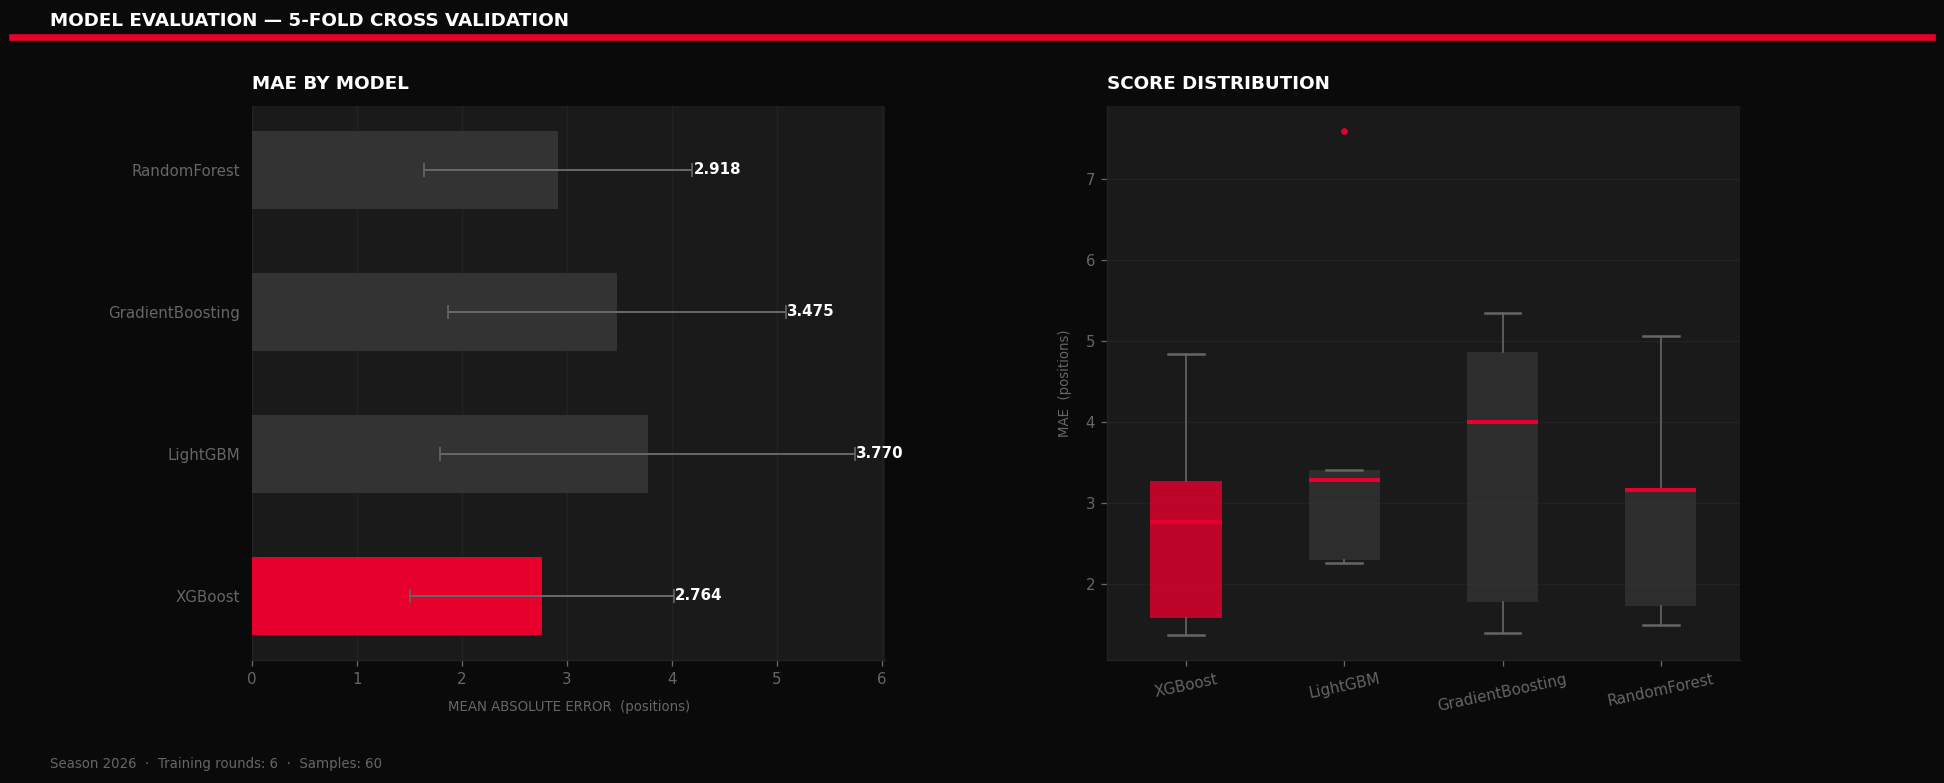

✅ Saved: model_comparison.png


In [9]:
# ============================================================
# CELL 8 — Model Comparison Visualisation  [F1 Theme]
# ============================================================

assert cv_results, "❌ Corre a Célula 7 primeiro!"

names  = list(cv_results.keys())
means  = [cv_results[n]["MAE_mean"] for n in names]
stds   = [cv_results[n]["MAE_std"]  for n in names]

fig = plt.figure(figsize=(16, 6), facecolor=F1_BG)
fig.suptitle("MODEL EVALUATION — 5-FOLD CROSS VALIDATION",
             color=F1_WHITE, fontsize=11, fontweight="bold",
             x=0.02, ha="left", y=1.01)

# Linha vermelha de acento no topo
fig.add_artist(plt.Line2D([0, 1], [0.975, 0.975], transform=fig.transFigure,
                           color=F1_RED, linewidth=4, zorder=10))

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

bar_colors = [F1_RED if n == best_model_name else "#333333" for n in names]

# ── Bar chart ──
bars = ax1.barh(names, means, xerr=stds,
                color=bar_colors, edgecolor="none",
                capsize=4, error_kw={"ecolor": F1_MUTED, "linewidth": 1.2},
                height=0.55)

ax1.set_xlabel("MEAN ABSOLUTE ERROR  (positions)", color=F1_MUTED,
               fontsize=8, labelpad=8)
ax1.set_title("MAE BY MODEL", color=F1_WHITE, fontsize=11,
              fontweight="bold", loc="left", pad=10)
ax1.spines["left"].set_visible(False)
ax1.tick_params(left=False)
ax1.xaxis.grid(True, color="#222", linewidth=0.8)
ax1.set_axisbelow(True)

for bar, val, std in zip(bars, means, stds):
    ax1.text(val + std + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", color=F1_WHITE,
             fontsize=9, fontweight="bold")

# Star no melhor
best_idx = names.index(best_model_name)
ax1.text(0.002, best_idx,
         "  ★ BEST", va="center", color=F1_RED,
         fontsize=8, fontweight="bold")

# ── Box plot ──
bp = ax2.boxplot(
    [cv_results[n]["scores"] for n in names],
    vert=True, patch_artist=True, labels=names,
    medianprops=dict(color=F1_RED, linewidth=2.5),
    whiskerprops=dict(color=F1_MUTED, linewidth=1),
    capprops=dict(color=F1_MUTED, linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor=F1_RED,
                    markersize=4, linestyle="none", markeredgewidth=0),
    boxprops=dict(linewidth=0),
)
for patch, c in zip(bp["boxes"], bar_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)

ax2.set_ylabel("MAE  (positions)", color=F1_MUTED, fontsize=8, labelpad=8)
ax2.set_title("SCORE DISTRIBUTION", color=F1_WHITE, fontsize=11,
              fontweight="bold", loc="left", pad=10)
ax2.tick_params(axis="x", rotation=12)
ax2.yaxis.grid(True, color="#222", linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines["bottom"].set_color(F1_BORDER)

# Acento vermelho nos dois axes
for ax in [ax1, ax2]:
    ax.set_facecolor(F1_CARD)
    for spine in ax.spines.values():
        spine.set_color(F1_BORDER)

# Sub-label
fig.text(0.02, -0.04,
         f"Season {SEASON}  ·  Training rounds: {df_clean['Round'].nunique()}  ·  Samples: {len(X_scaled)}",
         color=F1_MUTED, fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=180, bbox_inches="tight", facecolor=F1_BG)
plt.show()
print("✅ Saved: model_comparison.png")

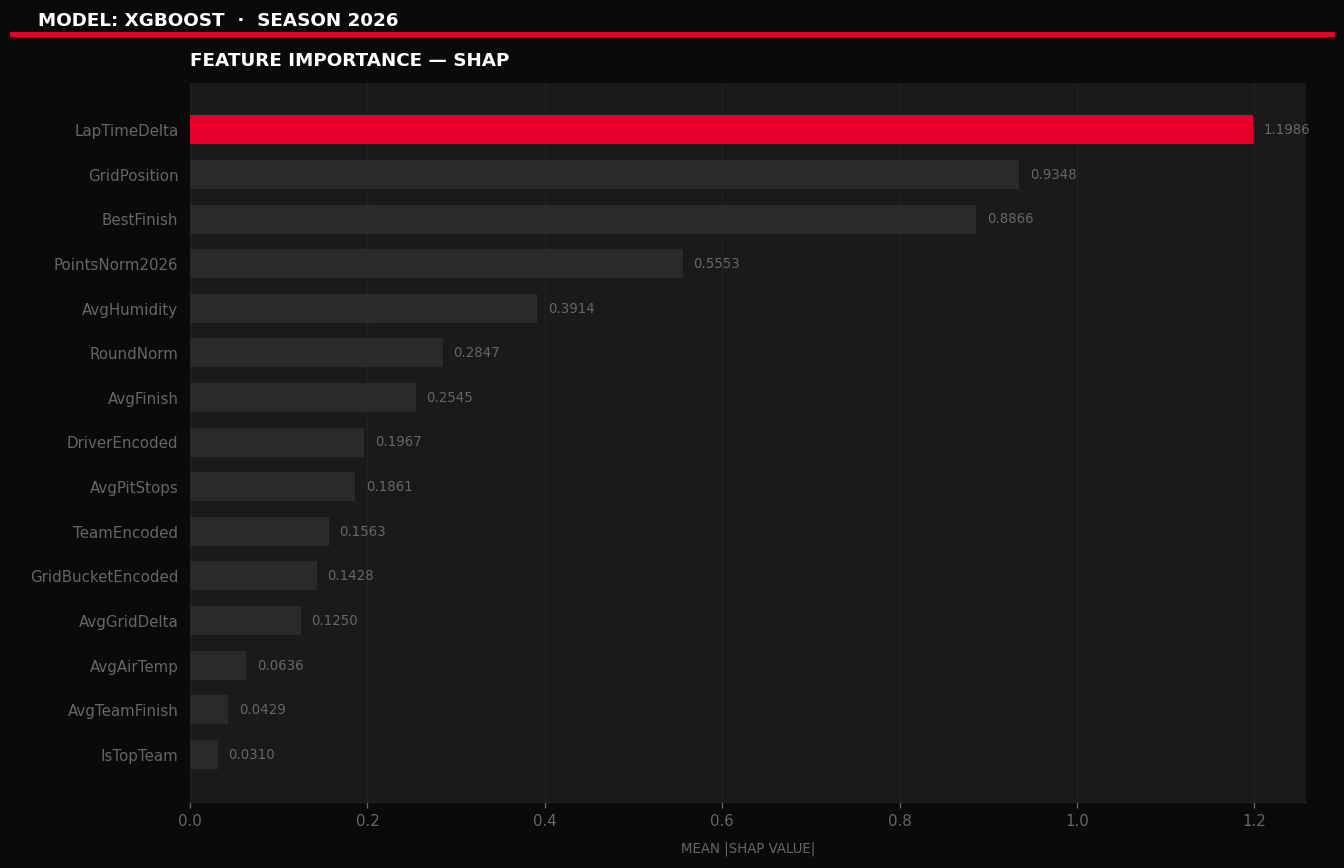

✅ Saved: feature_importance.png


In [10]:
# ============================================================
# CELL 9 — Feature Importance  [F1 Theme]
# ============================================================

try:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_scaled)
    use_shap    = True
except Exception as e:
    print(f"⚠️  SHAP fallback: {e}")
    use_shap = False

fig, ax = plt.subplots(figsize=(11, 7), facecolor=F1_BG)
ax.set_facecolor(F1_CARD)

if use_shap:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feat_df = pd.DataFrame({"Feature": FEATURES, "Importance": mean_abs_shap})
else:
    feat_df = pd.DataFrame({
        "Feature": FEATURES,
        "Importance": best_model.feature_importances_
    })

feat_df = feat_df.sort_values("Importance", ascending=True).tail(15)

colors_bar = [F1_RED if feat_df["Importance"].iloc[-1] == v else "#2a2a2a"
              for v in feat_df["Importance"]]
colors_bar[-1] = F1_RED   # top feature sempre a vermelho

bars = ax.barh(feat_df["Feature"], feat_df["Importance"],
               color=colors_bar, edgecolor="none", height=0.65)

# Valor no fim de cada barra
for bar, val in zip(bars, feat_df["Importance"]):
    ax.text(val + feat_df["Importance"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", color=F1_MUTED, fontsize=8)

ax.set_xlabel("MEAN |SHAP VALUE|" if use_shap else "FEATURE IMPORTANCE",
              color=F1_MUTED, fontsize=8, labelpad=8)
ax.set_title("FEATURE IMPORTANCE" + (" — SHAP" if use_shap else ""),
             color=F1_WHITE, fontsize=11, fontweight="bold", loc="left", pad=10)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(F1_BORDER)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, color="#222", linewidth=0.8)
ax.set_axisbelow(True)

fig.add_artist(plt.Line2D([0, 1], [1, 1], transform=fig.transFigure,
                           color=F1_RED, linewidth=3))
fig.text(0.02, 1.01, f"MODEL: {best_model_name.upper()}  ·  SEASON {SEASON}",
         color=F1_WHITE, fontsize=11, fontweight="bold",
         transform=fig.transFigure)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=180, bbox_inches="tight", facecolor=F1_BG)
plt.show()
print("✅ Saved: feature_importance.png")

In [11]:
# ============================================================
# CELL 10 — 2026 Spanish GP Prediction
# ============================================================

print("📡 Loading 2026 Spanish GP Qualifying...")
try:
    quali = fastf1.get_session(SEASON, TARGET_EVENT, "Q")
    quali.load(laps=True, telemetry=False, weather=False, messages=False)

    q_best = (
        quali.laps.pick_quicklaps()
        .groupby("Driver")["LapTime"]
        .min()
        .reset_index()
        .rename(columns={"Driver":"Abbreviation","LapTime":"QualiTime"})
    )
    q_best["QualiTimeSeconds"] = q_best["QualiTime"].dt.total_seconds()

    df_grid = quali.results[[
        "DriverNumber","Abbreviation","FullName","TeamName","Position"
    ]].copy()
    df_grid.columns = ["DriverNumber","Abbreviation","FullName","Team","GridPosition"]
    df_grid["GridPosition"] = pd.to_numeric(df_grid["GridPosition"], errors="coerce")
    df_grid = df_grid.merge(q_best[["Abbreviation","QualiTimeSeconds"]], on="Abbreviation", how="left")
    print(f"✅ Qualifying loaded: {len(df_grid)} drivers")

except Exception as e:
    print(f"⚠️  Fallback to manual grid ({e})")
    # Preenche com a grelha real de Barcelona 2026 depois do qualifying
    df_grid = pd.DataFrame({
        "Abbreviation": ["NOR","VER","LEC","PIA","HAM","RUS","ALO","SAI","ANT","HUL",
                         "GAS","ALB","LIN","STR","BEA","LAW","BOR","COL","HAD","OCO","PER","BOT"],
        "FullName":     ["Lando Norris","Max Verstappen","Charles Leclerc","Oscar Piastri",
                         "Lewis Hamilton","George Russell","Fernando Alonso","Carlos Sainz",
                         "Kimi Antonelli","Nico Hulkenberg","Pierre Gasly","Alexander Albon",
                         "Arvid Lindblad","Lance Stroll","Oliver Bearman","Liam Lawson",
                         "Gabriel Bortoleto","Franco Colapinto","Isack Hadjar","Esteban Ocon","Sergio Perez","Valtteri Bottas"],
        "Team":         ["McLaren","Red Bull Racing","Ferrari","McLaren",
                         "Ferrari","Mercedes","Aston Martin F1 Team","Williams",
                         "Mercedes","Audi","Alpine","Williams",
                         "Racing Bulls","Aston Martin F1 Team","Haas","Racing Bulls",
                         "Audi","Alpine","Red Bull Racing","Haas", "Cadillac", "Cadillac"],
        "GridPosition": list(range(1, 23)),
        "QualiTimeSeconds": [80.5 + i*0.05 for i in range(22)],
    })

# Merge com stats de 2026
df_pred = df_grid.copy()
df_pred["Round"]    = completed["RoundNumber"].max() + 1
df_pred["RoundNorm"] = 1.0   # fim de época — máximo desenvolvimento

df_pred = df_pred.merge(driver_stats_2026[[
    "Abbreviation","AvgFinish","BestFinish","PointsNorm2026",
    "AvgGridDelta","DNF_rate","AvgFastestLap","AvgPitStops"
]], on="Abbreviation", how="left")

df_pred = df_pred.merge(team_stats_2026[[
    "Team","TeamPointsNorm","AvgTeamFinish","TeamDNF_rate"
]], on="Team", how="left")

# Weather típico de Barcelona em Junho
df_pred["AvgAirTemp"]   = 28.0
df_pred["AvgTrackTemp"] = 48.0
df_pred["AvgHumidity"]  = 40.0
df_pred["AvgWindSpeed"] = 12.0
df_pred["Rainfall"]     = 0
df_pred["LapTimeDelta"] = df_pred["QualiTimeSeconds"] - df_pred["QualiTimeSeconds"].min()

# Bucket grelha
bins_pred   = [0,1,2,5,10,20]
labels_pred = ["Pole","FrontRow","Top5","Midfield","Back"]
df_pred["GridBucket"] = pd.cut(df_pred["GridPosition"], bins=bins_pred,
                                labels=labels_pred, right=True)

# Encodings — handle unseen labels
def safe_encode(encoder, values):
    classes = list(encoder.classes_)
    out = []
    for v in values:
        out.append(classes.index(v) if v in classes else 0)
    return np.array(out)

df_pred["DriverEncoded"]     = safe_encode(le_driver, df_pred["Abbreviation"].astype(str))
df_pred["TeamEncoded"]       = safe_encode(le_team,   df_pred["Team"].astype(str))
df_pred["GridBucketEncoded"] = safe_encode(le_bucket, df_pred["GridBucket"].astype(str))

top6_teams = (team_stats_2026.sort_values("TotalTeamPoints", ascending=False)
              .head(6)["Team"].tolist())
df_pred["IsTopTeam"] = df_pred["Team"].apply(lambda t: 1 if t in top6_teams else 0)

# Feature matrix
X_pred_raw = df_pred[FEATURES].copy()
for col in X_pred_raw.columns:
    X_pred_raw[col] = X_pred_raw[col].fillna(X_pred_raw[col].median())

X_pred_scaled = pd.DataFrame(scaler.transform(X_pred_raw), columns=FEATURES)

df_pred["PredictedPosition_raw"] = best_model.predict(X_pred_scaled)
df_pred["PredictedPosition"]     = df_pred["PredictedPosition_raw"].rank(method="first").astype(int)
df_pred_sorted = df_pred.sort_values("PredictedPosition").reset_index(drop=True)

print("\n🏎️  2026 Spanish GP — Top 10 Predicted:")
print(df_pred_sorted.head(10)[["PredictedPosition","Abbreviation","FullName","Team","GridPosition"]].to_string(index=False))

events      WARNING 	Correcting user input 'Barcelona Gran Prix' to 'Barcelona Grand Prix'
core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


📡 Loading 2026 Spanish GP Qualifying...


core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']


✅ Qualifying loaded: 22 drivers

🏎️  2026 Spanish GP — Top 10 Predicted:
 PredictedPosition Abbreviation        FullName            Team  GridPosition
                 1          ANT  Kimi Antonelli        Mercedes         3.000
                 2          RUS  George Russell        Mercedes         1.000
                 3          NOR    Lando Norris         McLaren         4.000
                 4          HAM  Lewis Hamilton         Ferrari         2.000
                 5          VER  Max Verstappen Red Bull Racing         5.000
                 6          PIA   Oscar Piastri         McLaren         7.000
                 7          LEC Charles Leclerc         Ferrari        10.000
                 8          GAS    Pierre Gasly          Alpine        14.000
                 9          HAD    Isack Hadjar Red Bull Racing         6.000
                10          LAW     Liam Lawson    Racing Bulls         8.000


In [12]:
print(df_pred_sorted.columns.tolist())

['DriverNumber', 'Abbreviation', 'FullName', 'Team', 'GridPosition', 'QualiTimeSeconds', 'Round', 'RoundNorm', 'AvgFinish', 'BestFinish', 'PointsNorm2026', 'AvgGridDelta', 'DNF_rate', 'AvgFastestLap', 'AvgPitStops', 'TeamPointsNorm', 'AvgTeamFinish', 'TeamDNF_rate', 'AvgAirTemp', 'AvgTrackTemp', 'AvgHumidity', 'AvgWindSpeed', 'Rainfall', 'LapTimeDelta', 'GridBucket', 'DriverEncoded', 'TeamEncoded', 'GridBucketEncoded', 'IsTopTeam', 'PredictedPosition_raw', 'PredictedPosition']


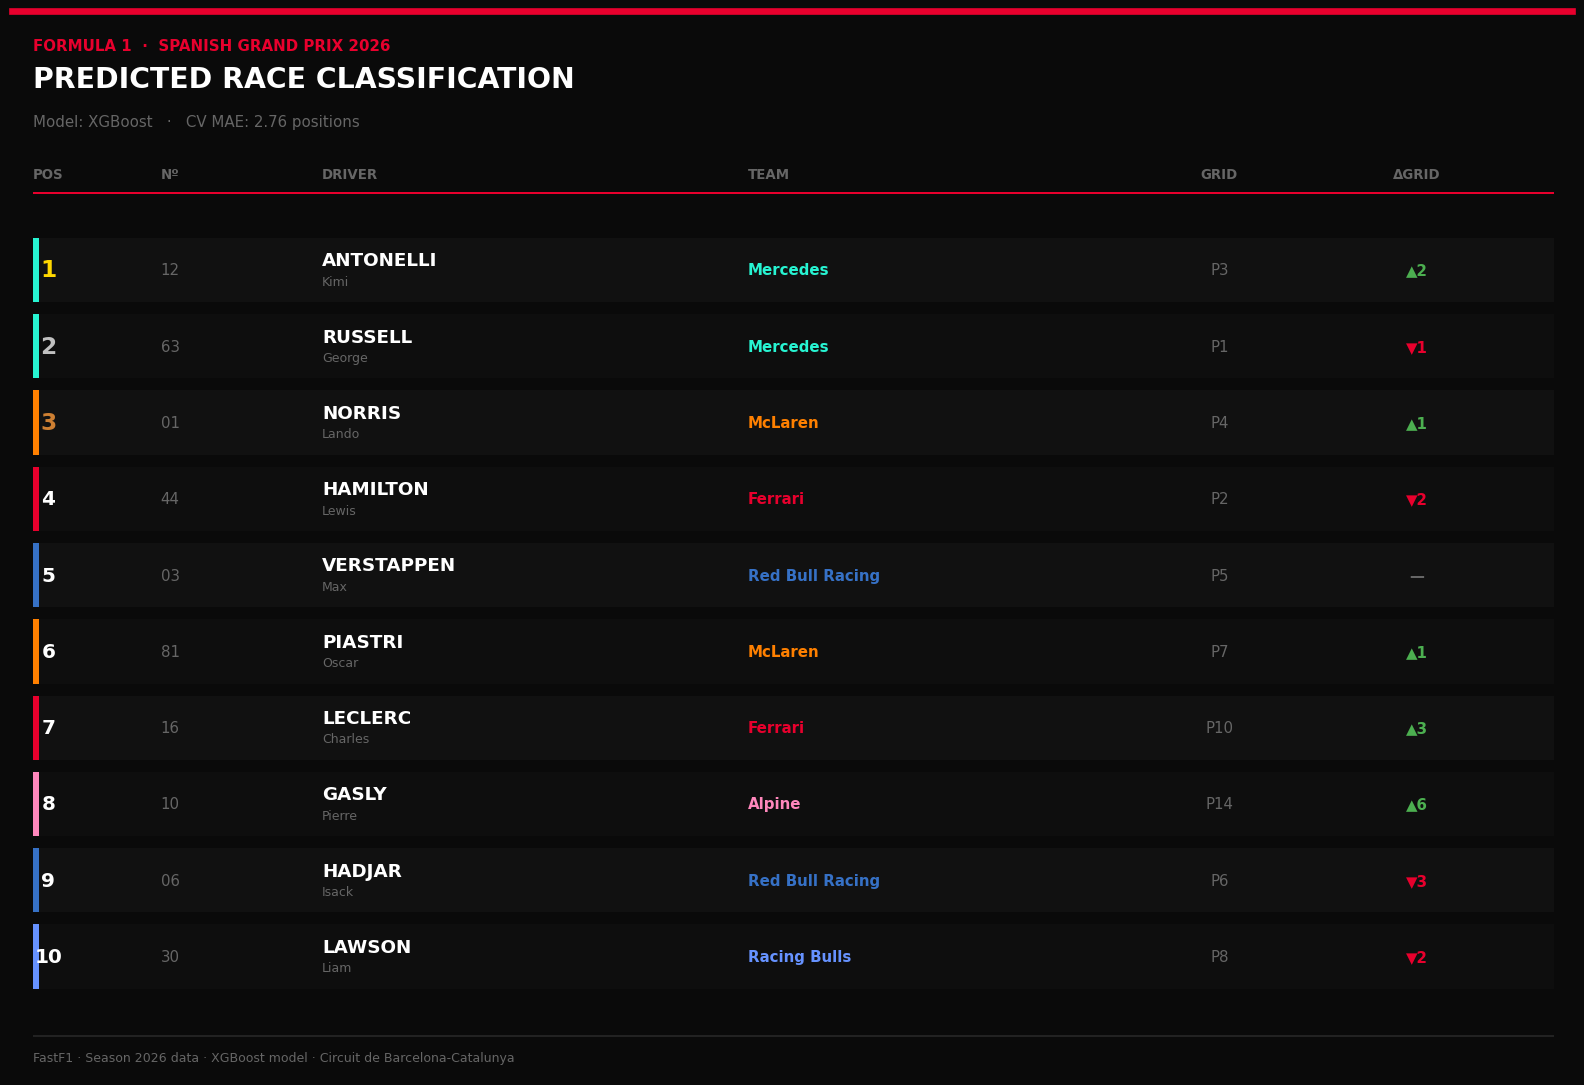

✅ Saved: f1_barcelona_top10_prediction.png


In [13]:
# ============================================================
# CELL 11 — Top 10 Prediction Table 
# ============================================================

top10 = df_pred_sorted.head(10)[[
   "PredictedPosition", "Abbreviation", "FullName", "Team", "GridPosition", "DriverNumber"
]].copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 9), facecolor=F1_BG)
ax.set_facecolor(F1_BG)
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 12.5)

# ── Red accent line no topo ─────────────────────────────────
fig.add_artist(plt.Line2D([0, 1], [1, 1], transform=fig.transFigure,
                           color=F1_RED, linewidth=4))

# ── Título ──────────────────────────────────────────────────
ax.text(0.0, 12.2, "FORMULA 1  ·  SPANISH GRAND PRIX 2026",
        color=F1_RED, fontsize=9, fontweight="bold", va="bottom")
ax.text(0.0, 11.7, "PREDICTED RACE CLASSIFICATION",
        color=F1_WHITE, fontsize=17, fontweight="bold", va="bottom")
ax.text(0.0, 11.25,
        f"Model: {best_model_name}   ·   CV MAE: {cv_results[best_model_name]['MAE_mean']:.2f} positions",
        color=F1_MUTED, fontsize=9, va="bottom")

# ── Colunas ─────────────────────────────────────────────────
col_x     = [0.01, 0.09, 0.19, 0.47, 0.78, 0.91]
col_labels = ["POS", "Nº", "DRIVER", "TEAM", "GRID", "ΔGRID"]
col_align  = ["center", "center", "left", "left", "center", "center"]

# Header
for x, label, align in zip(col_x, col_labels, col_align):
    ax.text(x, 10.7, label, color=F1_MUTED, fontsize=8,
            fontweight="bold", ha=align, va="center")

# Linha separadora do header
ax.add_patch(FancyBboxPatch((0, 10.45), 1.0, 0.02,
             boxstyle="square,pad=0", facecolor=F1_RED, linewidth=0))

# ── Rows ────────────────────────────────────────────────────
for i, row in top10.iterrows():
    y_center = 9.5 - i * 0.95
    y_box    = y_center - 0.40

    t_color  = team_color(row["Team"])
    is_podium = i < 3

    # Fundo da linha
    bg = F1_PANEL if i % 2 == 0 else "#0e0e0e"
    ax.add_patch(FancyBboxPatch((0, y_box), 1.0, 0.80,
                 boxstyle="square,pad=0", facecolor=bg, linewidth=0))

    # Barra colorida da equipa (lado esquerdo)
    ax.add_patch(FancyBboxPatch((0, y_box), 0.004, 0.80,
                 boxstyle="square,pad=0", facecolor=t_color, linewidth=0))

    # Posição
    pos_txt = str(i + 1)
    pos_color = F1_GOLD if i == 0 else (F1_SILVER if i == 1 else
                (F1_BRONZE if i == 2 else F1_WHITE))
    ax.text(col_x[0], y_center, pos_txt,
            color=pos_color, fontsize=14 if is_podium else 12,
            fontweight="bold", ha="center", va="center")

    # Número do piloto (posição na grelha de qualifying = número de corrida aqui)
    ax.text(col_x[1], y_center, f"{int(row['DriverNumber']):02d}",
            color=F1_MUTED, fontsize=9, ha="center", va="center")

    # Nome do piloto — apelido em bold + primeiro nome pequeno
    full = row["FullName"].split()
    firstname = " ".join(full[:-1]) if len(full) > 1 else ""
    lastname  = full[-1].upper()
    ax.text(col_x[2], y_center + 0.12, lastname,
            color=F1_WHITE, fontsize=11, fontweight="bold",
            ha="left", va="center")
    ax.text(col_x[2], y_center - 0.14, firstname,
            color=F1_MUTED, fontsize=7.5, ha="left", va="center")

    # Team name com cor da equipa
    ax.text(col_x[3], y_center, row["Team"],
            color=t_color, fontsize=9, ha="left", va="center",
            fontweight="bold")

    # Grid position
    ax.text(col_x[4], y_center, f"P{int(row['GridPosition'])}",
            color=F1_MUTED, fontsize=9, ha="center", va="center")

    # Delta grelha → posição prevista
    delta = int(row["GridPosition"]) - (i + 1)
    d_str   = f"▲{delta}" if delta > 0 else (f"▼{abs(delta)}" if delta < 0 else "—")
    d_color = "#4CAF50" if delta > 0 else (F1_RED if delta < 0 else F1_MUTED)
    ax.text(col_x[5], y_center, d_str,
            color=d_color, fontsize=9, fontweight="bold",
            ha="center", va="center")

# Linha de separação no fundo
ax.add_patch(FancyBboxPatch((0, -0.05), 1.0, 0.02,
             boxstyle="square,pad=0", facecolor=F1_BORDER, linewidth=0))
ax.text(0.0, -0.35,
        f"FastF1 · Season {SEASON} data · {best_model_name} model · Circuit de Barcelona-Catalunya",
        color=F1_MUTED, fontsize=7.5)

plt.tight_layout()
plt.savefig("f1_barcelona_top10_prediction.png", dpi=200,
            bbox_inches="tight", facecolor=F1_BG)
plt.show()
print("✅ Saved: f1_barcelona_top10_prediction.png")

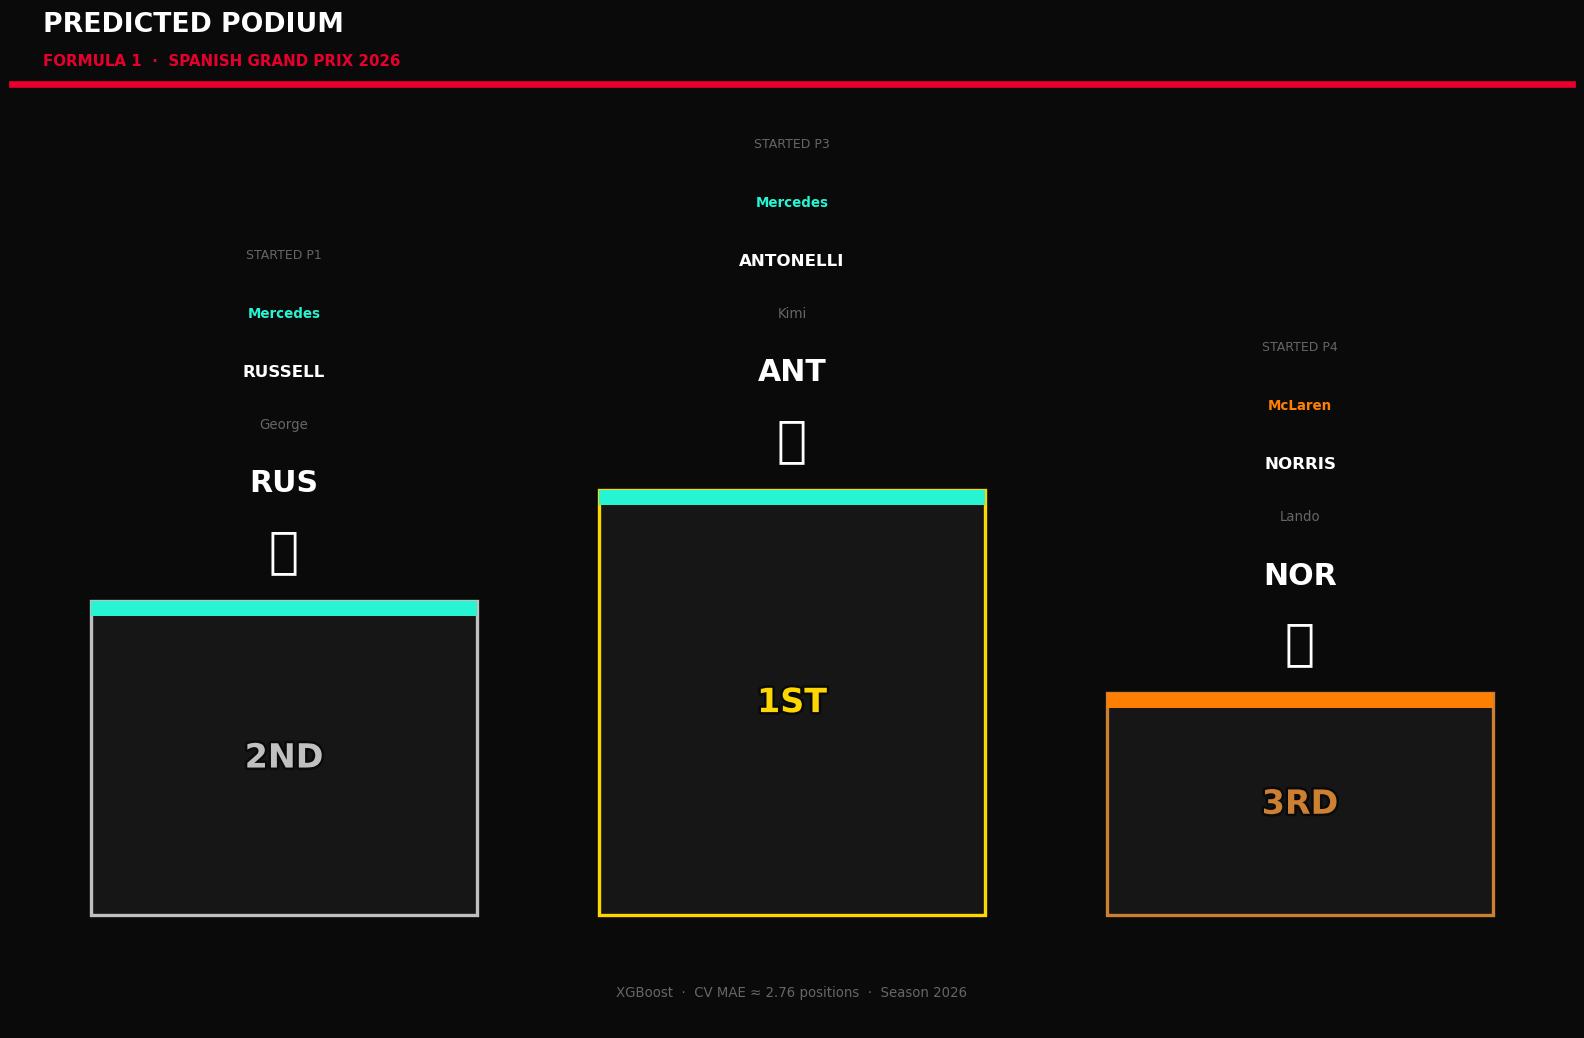

✅ Saved: f1_barcelona_podium.png


In [14]:
# ============================================================
# CELL 12 — Podium Visual  [F1 Theme]
# ============================================================

podium = df_pred_sorted.head(3).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 8), facecolor=F1_BG)
ax.set_facecolor(F1_BG)
ax.axis("off")
ax.set_xlim(0, 3)
ax.set_ylim(-0.3, 2.2)

# Acento vermelho no topo
fig.add_artist(plt.Line2D([0, 1], [1, 1], transform=fig.transFigure,
                           color=F1_RED, linewidth=4))

# Título
fig.text(0.02, 1.02, f"FORMULA 1  ·  SPANISH GRAND PRIX 2026",
         color=F1_RED, fontsize=9, fontweight="bold",
         transform=fig.transFigure)
fig.text(0.02, 1.055, "PREDICTED PODIUM",
         color=F1_WHITE, fontsize=16, fontweight="bold",
         transform=fig.transFigure)

# Layout: P2 esquerda, P1 centro, P3 direita
layout = [
    {"pos_idx": 1, "x": 0.5,  "h": 0.85, "label": "2ND",  "medal": F1_SILVER},
    {"pos_idx": 0, "x": 1.5,  "h": 1.15, "label": "1ST",  "medal": F1_GOLD},
    {"pos_idx": 2, "x": 2.5,  "h": 0.60, "label": "3RD",  "medal": F1_BRONZE},
]

for slot in layout:
    row     = podium.iloc[slot["pos_idx"]]
    x       = slot["x"]
    h       = slot["h"]
    t_color = team_color(row["Team"])

    # Bloco do pódio
    ax.add_patch(FancyBboxPatch(
        (x - 0.38, 0), 0.76, h,
        boxstyle="square,pad=0",
        facecolor="#161616", edgecolor=slot["medal"],
        linewidth=2, zorder=2
    ))

    # Faixa de cor da equipa no topo do bloco
    ax.add_patch(FancyBboxPatch(
        (x - 0.38, h - 0.04), 0.76, 0.04,
        boxstyle="square,pad=0",
        facecolor=t_color, linewidth=0, zorder=3
    ))

    # Número da posição dentro do bloco
    ax.text(x, h / 2, slot["label"],
            ha="center", va="center", color=slot["medal"],
            fontsize=20, fontweight="bold", zorder=4,
            path_effects=[pe.withStroke(linewidth=3, foreground=F1_BG)])

    # Medalha / emoji
    emoji_map = {F1_GOLD: "🥇", F1_SILVER: "🥈", F1_BRONZE: "🥉"}
    ax.text(x, h + 0.07, emoji_map[slot["medal"]],
            ha="center", va="bottom", fontsize=30, zorder=4)

    # Abreviatura do piloto
    ax.text(x, h + 0.28, row["Abbreviation"],
            ha="center", va="bottom",
            color=F1_WHITE, fontsize=18, fontweight="bold", zorder=4)

    # Nome completo
    full  = row["FullName"].split()
    fname = " ".join(full[:-1])
    lname = full[-1].upper()
    ax.text(x, h + 0.46, fname,
            ha="center", va="bottom", color=F1_MUTED, fontsize=8, zorder=4)
    ax.text(x, h + 0.60, lname,
            ha="center", va="bottom", color=F1_WHITE,
            fontsize=10, fontweight="bold", zorder=4)

    # Equipa com cor
    ax.text(x, h + 0.76, row["Team"],
            ha="center", va="bottom", color=t_color,
            fontsize=8, fontweight="bold", zorder=4)

    # Grid de partida
    ax.text(x, h + 0.92, f"STARTED P{int(row['GridPosition'])}",
            ha="center", va="bottom", color=F1_MUTED,
            fontsize=7.5, zorder=4)

# Rodapé
ax.text(1.5, -0.22,
        f"{best_model_name}  ·  CV MAE ≈ {cv_results[best_model_name]['MAE_mean']:.2f} positions  ·  Season {SEASON}",
        ha="center", color=F1_MUTED, fontsize=8)

plt.tight_layout()
plt.savefig("f1_barcelona_podium.png", dpi=200,
            bbox_inches="tight", facecolor=F1_BG)
plt.show()
print("✅ Saved: f1_barcelona_podium.png")

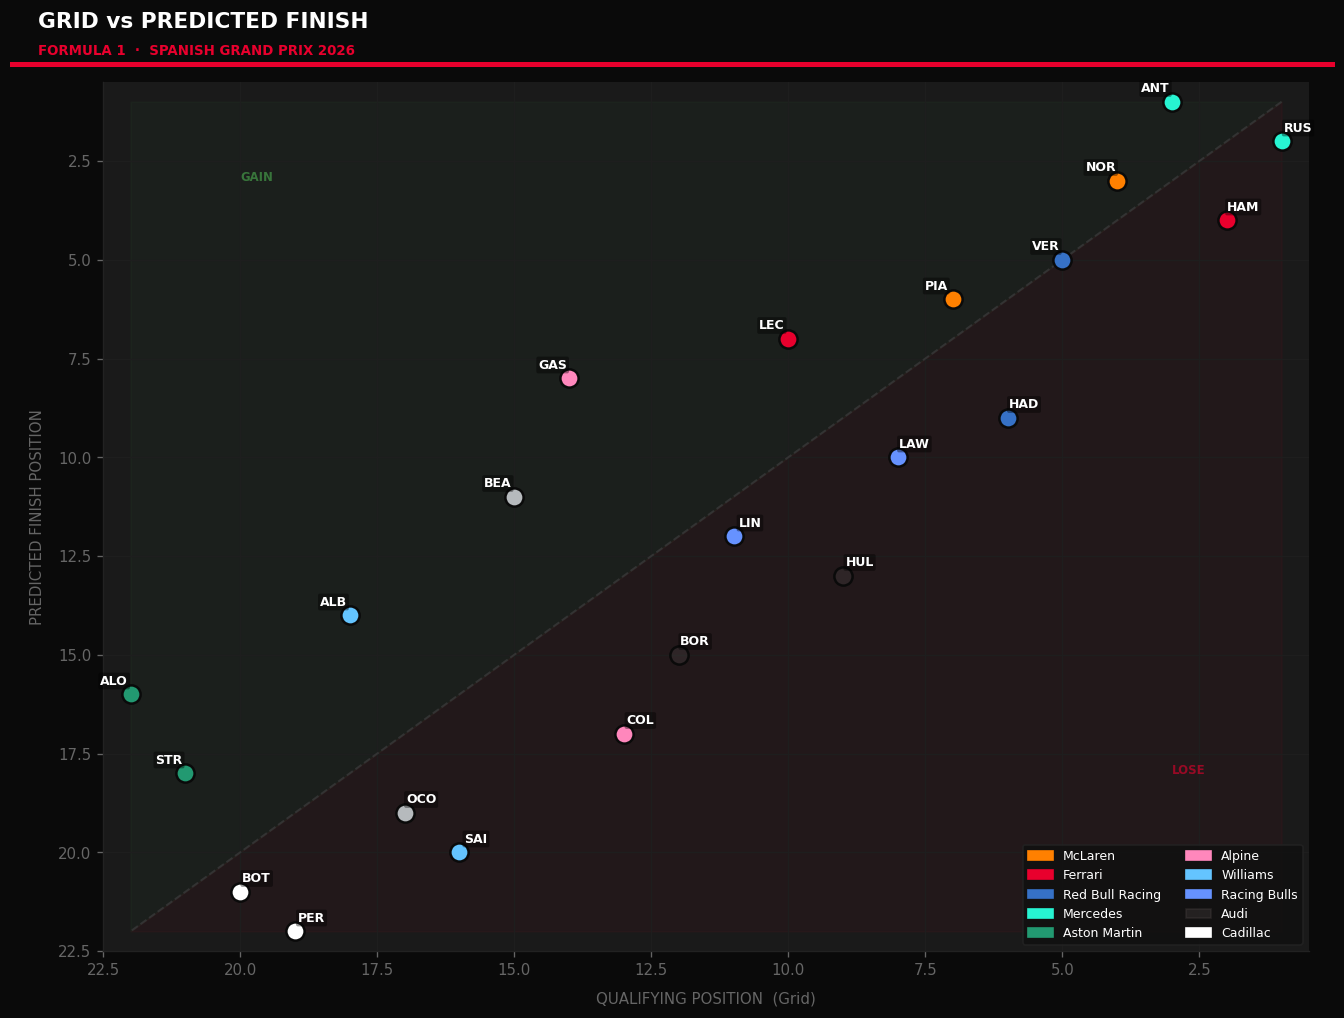

✅ Saved: f1_barcelona_scatter.png


In [15]:
# ============================================================
# CELL 13 — Grid vs Predicted Finish  [F1 Theme]
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8), facecolor=F1_BG)
ax.set_facecolor(F1_CARD)

# Diagonal de referência
ax.plot([1, 22], [1, 22], color="#333333", linestyle="--",
        linewidth=1.2, zorder=1, label="No change")

for _, row in df_pred_sorted.iterrows():
    gp  = row["GridPosition"]
    pp  = row["PredictedPosition"]
    tc  = team_color(row["Team"])
    abr = row["Abbreviation"]
    delta = gp - pp

    ax.scatter(gp, pp, color=tc, s=120, zorder=3,
               edgecolors=F1_BG, linewidths=1.5)

    # Offset do label para não sobrepor
    offset_x = 0.3 if delta >= 0 else -0.3
    offset_y = -0.5
    ax.annotate(
        abr,
        xy=(gp, pp),
        xytext=(gp + offset_x, pp + offset_y),
        color=F1_WHITE, fontsize=7.5, fontweight="bold",
        ha="center", va="top",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="#00000066",
                  edgecolor="none"),
        zorder=4
    )

# Regiões de ganho / perda
ax.fill_between([1, 22], [1, 22], [1, 1],
                alpha=0.04, color="#4CAF50", zorder=0)
ax.fill_between([1, 22], [22, 22], [1, 22],
                alpha=0.04, color=F1_RED, zorder=0)

ax.text(20, 3,  "GAIN", color="#4CAF50", fontsize=7,
        fontweight="bold", alpha=0.6)
ax.text(3,   18, "LOSE", color=F1_RED,    fontsize=7,
        fontweight="bold", alpha=0.6)

ax.set_xlabel("QUALIFYING POSITION  (Grid)", color=F1_MUTED,
              fontsize=9, labelpad=8)
ax.set_ylabel("PREDICTED FINISH POSITION", color=F1_MUTED,
              fontsize=9, labelpad=8)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlim(22.5, 0.5)
ax.set_ylim(22.5, 0.5)
ax.xaxis.grid(True, color="#1e1e1e", linewidth=0.8)
ax.yaxis.grid(True, color="#1e1e1e", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color(F1_BORDER)

# Team colour legend
handles = [mpatches.Patch(color=v, label=k)
           for k, v in TEAM_COLORS.items()
           if k in df_pred_sorted["Team"].values]
ax.legend(handles=handles, loc="lower right", fontsize=7.5,
          framealpha=0.9, ncol=2)

# Título
fig.add_artist(plt.Line2D([0, 1], [1, 1], transform=fig.transFigure,
                           color=F1_RED, linewidth=3))
fig.text(0.02, 1.01, "FORMULA 1  ·  SPANISH GRAND PRIX 2026",
         color=F1_RED, fontsize=8, fontweight="bold",
         transform=fig.transFigure)
fig.text(0.02, 1.038, "GRID vs PREDICTED FINISH",
         color=F1_WHITE, fontsize=13, fontweight="bold",
         transform=fig.transFigure)

plt.tight_layout()
plt.savefig("f1_barcelona_scatter.png", dpi=200,
            bbox_inches="tight", facecolor=F1_BG)
plt.show()
print("✅ Saved: f1_barcelona_scatter.png")

In [16]:
# ============================================================
# CELL 14 — Final Prediction Report
# ============================================================

print("=" * 60)
print("       F1 BARCELONA 2026 — PREDICTION REPORT")
print("=" * 60)
print(f"\n  Best Model       : {best_model_name}")
print(f"  CV MAE (avg)     : {cv_results[best_model_name]['MAE_mean']:.4f} positions")
print(f"  CV MAE (std)     : {cv_results[best_model_name]['MAE_std']:.4f} positions")
print(f"  Features used    : {len(FEATURES)}")
print(f"  Training samples : {len(X_scaled)}")
print(f"  Season           : {SEASON} (rounds used: {df_clean['Round'].nunique()})")
print(f"  Rounds trained   : {sorted(df_clean['Round'].unique().tolist())}")

print("\n  📊 All Model CV MAEs:")
for name, res in sorted(cv_results.items(), key=lambda x: x[1]["MAE_mean"]):
    marker = " ← BEST" if name == best_model_name else ""
    print(f"     {name:>25} : {res['MAE_mean']:.4f} ± {res['MAE_std']:.4f}{marker}")

print(f"\n{'=' * 60}")
print("  🏎️  PREDICTED RACE CLASSIFICATION — TOP 10")
print(f"{'=' * 60}")
print(f"  {'POS':>4}  {'DRIVER':>6}  {'FULL NAME':<22}  {'TEAM':<22}  {'GRID':>4}  {'Δ':>4}")
print(f"  {'-' * 68}")

for _, row in df_pred_sorted.head(10).iterrows():
    pos   = int(row["PredictedPosition"])
    delta = int(row["GridPosition"]) - pos
    d_str = f"+{delta}" if delta > 0 else (str(delta) if delta < 0 else " 0")
    medal = {1: "🥇", 2: "🥈", 3: "🥉"}.get(pos, "  ")
    print(f"  {medal} {pos:>2}  {row['Abbreviation']:>6}  {row['FullName']:<22}  "
          f"{row['Team']:<22}  P{int(row['GridPosition']):>2}  {d_str:>4}")

print(f"\n{'=' * 60}")
print(f"  MAE ≈ {cv_results[best_model_name]['MAE_mean']:.2f} positions margin of error")
print(f"  Model trained on {SEASON} season data only")
print("=" * 60)

       F1 BARCELONA 2026 — PREDICTION REPORT

  Best Model       : XGBoost
  CV MAE (avg)     : 2.7635 positions
  CV MAE (std)     : 1.2573 positions
  Features used    : 20
  Training samples : 60
  Season           : 2026 (rounds used: 6)
  Rounds trained   : [1, 2, 3, 4, 5, 6]

  📊 All Model CV MAEs:
                       XGBoost : 2.7635 ± 1.2573 ← BEST
                  RandomForest : 2.9178 ± 1.2781
              GradientBoosting : 3.4749 ± 1.6119
                      LightGBM : 3.7699 ± 1.9745

  🏎️  PREDICTED RACE CLASSIFICATION — TOP 10
   POS  DRIVER  FULL NAME               TEAM                    GRID     Δ
  --------------------------------------------------------------------
  🥇  1     ANT  Kimi Antonelli          Mercedes                P 3    +2
  🥈  2     RUS  George Russell          Mercedes                P 1    -1
  🥉  3     NOR  Lando Norris            McLaren                 P 4    +1
      4     HAM  Lewis Hamilton          Ferrari                 P 2    -2
  